# CNN-STM

## Import

In [1]:
import os  
os.environ['KMP_DUPLICATE_LIB_OK']='True' # fix dead kernel

In [2]:
import albumentations as A
import torch
import torch.nn as nn
import torch.optim as optim

from albumentations.pytorch import ToTensorV2
from torchvision import models

/scratch/user/al63rt.tran/my_envs/my_notebook-python-3.10.4/lib/python3.10/site-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


## Load Model

In [3]:
import ssl
import certifi
import urllib.request
from cnn_stm_utils import cnn_stm

# Set the default SSL context to use the  certificate bundle
ssl._create_default_https_context = ssl._create_unverified_context

# Alternatively, you can set the context for urllib globally
context = ssl.create_default_context(cafile=certifi.where())
opener = urllib.request.build_opener(urllib.request.HTTPSHandler(context=context))
urllib.request.install_opener(opener)

class_names = ["Uninhabited", "Empty", "Rebuilding", "Rebuilt"]
net = cnn_stm(num_classes=len(class_names))

## Prepare the Dataset

### Load Training/Testing Datasets

In [4]:
from pathlib import Path
from collections import Counter
from data_augmentation import cnn_only_augmentation

train_directory = Path(r"/scratch/user/al63rt.tran/Train")
validation_directory = Path(r"/scratch/user/al63rt.tran/Validation")

class_sampling = {
    "Uninhabited": "all",
    "Rebuilding": "all",
    "Empty": 800,
    "Rebuilt": 800,
}

augmentation_factors = {
    "Uninhabited": 8,
    "Rebuilding": 5,
}

### Set up train folders

In [5]:
from train_utils import (
    _build_address_list,
    build_train_loader,
    train_model,
    _live_plot,
)

from hybrid_architecture_utils import (
    build_sequence_and_still,
    SequenceDataset,
    StillDataset,
    build_validation_loader,
)

train_folders = sorted([p for p in train_directory.iterdir() if p.is_dir()])

train_addrs = []
for folder in train_folders:
    addrs_i, class_names_i = _build_address_list(str(folder), class_names=class_names)
    train_addrs.extend(addrs_i)

meta = {
    "train_addrs": train_addrs,
}

print("Train folders:", [p.name for p in train_folders])

Train folders: ['.ipynb_checkpoints', 'Train 2011', 'Train 2012', 'Train 2013', 'Train 2014', 'Train 2015', 'Train 2016']


### Set up sequence and still datasets

In [6]:
from data_augmentation import cnn_hybrid_augmentation

sequence_runs, still_runs = build_sequence_and_still(train_addrs,
                                                     run_min=3,
                                                     max_sequence_len=20,
                                                     max_still_frames=64)

sequence_aug, still_aug, base = cnn_hybrid_augmentation()

sequence_ds = SequenceDataset(
    sequence_runs=sequence_runs,
    addrs=train_addrs,
    aug_t=sequence_aug,
    base_t=base,
    augmentation_factors=augmentation_factors,
    class_names=class_names,
)

still_ds = StillDataset(
    leftovers_by_addr=still_runs,
    addrs=train_addrs,
    aug_t=still_aug,
    base_t=base,
    augmentation_factors=augmentation_factors,
    class_names=class_names,
)

### Set up validation dataset

In [7]:
minority_aug, base = cnn_only_augmentation()

augmentation_ds = {
    "aug_t": minority_aug,
    "base_t": base,
}

In [8]:
validation_base_t = base

validation_loader = None
validation_addrs = []

if validation_directory.exists():
    validation_folders = sorted([p for p in validation_directory.iterdir() if p.is_dir()])

    for folder in validation_folders:
        addrs_i, _ = _build_address_list(str(folder), class_names=class_names)
        validation_addrs.extend(addrs_i)

    validation_sequence_runs, validation_still_runs = build_sequence_and_still(
        validation_addrs,
        run_min=3,
        max_sequence_len=20,
        max_still_frames=64,
    )

    validation_loader = build_validation_loader(
        validation_addrs=validation_addrs,
        validation_sequence_runs=validation_sequence_runs,
        validation_still_runs=validation_still_runs,
        validation_base_t=validation_base_t,
        num_workers=4,
        pin_memory=True,
    )

    print("Validation folders:", [p.name for p in validation_folders])
    print("Validation addresses:", len(validation_addrs))
    print("Validation sequence runs:", len(validation_sequence_runs))
    print("Validation still addresses:", len(validation_still_runs))

Validation folders: ['.ipynb_checkpoints', 'Validation 2011', 'Validation 2012', 'Validation 2013', 'Validation 2014', 'Validation 2015', 'Validation 2016']
Validation addresses: 3532
Validation sequence runs: 3650
Validation still addresses: 1697


### DataLoader

In [9]:
from torch.utils.data import DataLoader

sequence_loader = DataLoader(
    sequence_ds,
    batch_size=1,
    shuffle=True,      
    num_workers=4,
    pin_memory=True,
    drop_last=False,
)

still_loader = DataLoader(
    still_ds,
    batch_size=1,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    drop_last=False,
)

### Freeze batch normalization

In [12]:
net.train()  

for m in net.modules():
    if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
        m.eval()  
        for p in m.parameters():
            p.requires_grad = False  

### Hyperparameters Setting

In [13]:
optimizer = torch.optim.AdamW(
    net.parameters(),
    lr=1e-5,
    weight_decay=1e-3,
)

lr = [1e-5, 1e-6]
lr_epochs = [1, 25]   

### Implement Training

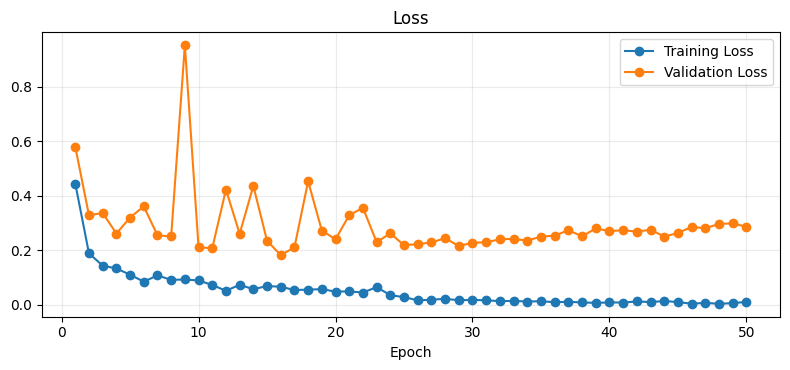

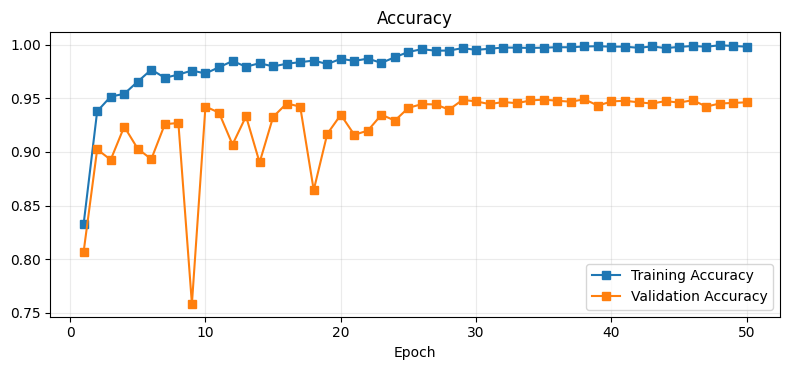

In [11]:
# Set training information directory
csv_path = r"/scratch/user/al63rt.tran/my_envs/my_notebook-python-3.10.4/designsafe/cnn_stm.csv"

history = train_model(
    model=net,
    epochs=50,
    optimizer=optimizer,
    mode="hybrid",
    lr=lr,
    lr_epochs=lr_epochs,
    device="cuda" if torch.cuda.is_available() else "cpu",
    colour="green",
    validation_loader=validation_loader,
    csv_path=csv_path,
    checkpoint_dir=r"/scratch/user/al63rt.tran/my_envs/my_notebook-python-3.10.4/designsafe/cnn_stm",
    checkpoint_prefix="cnn_stm",
    freeze_bn=True,
    plot_fn=_live_plot,
    class_sampling=class_sampling,
    augmentation_factors=augmentation_factors,
    augmentation_ds=augmentation_ds,
    meta=meta,
    class_names=class_names,
    seed=42,
    dropout_p=0.2,
    apply_dropout=True,
)

## Restore Best Model

In [13]:
device = "cuda" if torch.cuda.is_available() else "cpu"

path = Path("/scratch/user/al63rt.tran/my_envs/my_notebook-python-3.10.4/cnn-stm/cnn-stm_epoch_027.pth")

ckpt = torch.load(path, map_location=device)

# get actual weights
state_dict = ckpt["model_state_dict"] if "model_state_dict" in ckpt else ckpt

# if saved with DataParallel, remove "module." prefix
if len(state_dict) > 0 and next(iter(state_dict)).startswith("module."):
    state_dict = {k.replace("module.", "", 1): v for k, v in state_dict.items()}

net = net.to(device)
net.load_state_dict(state_dict, strict=True)
net.eval()

print("Loaded epoch:", ckpt.get("epoch"))
print("Validation loss:", ckpt.get("validation_loss"))

Loaded epoch: 27
Validation loss: 0.22933315850809066


## Plot Confusion Matrix

In [22]:
from confusion_hybrid import confusion_matrix

eval addrs:   0%|          | 0/3532 [00:00<?, ?it/s]

              precision    recall  f1-score   support

 Uninhabited      0.722     0.929     0.812        14
       Empty      0.802     0.929     0.861       476
  Rebuilding      0.640     0.457     0.533        35
     Rebuilt      0.965     0.908     0.935      1172

    accuracy                          0.905      1697
   macro avg      0.782     0.806     0.785      1697
weighted avg      0.910     0.905     0.905      1697

Saved confusion matrix PNG to: /scratch/user/al63rt.tran/cm_cnn_stm.png


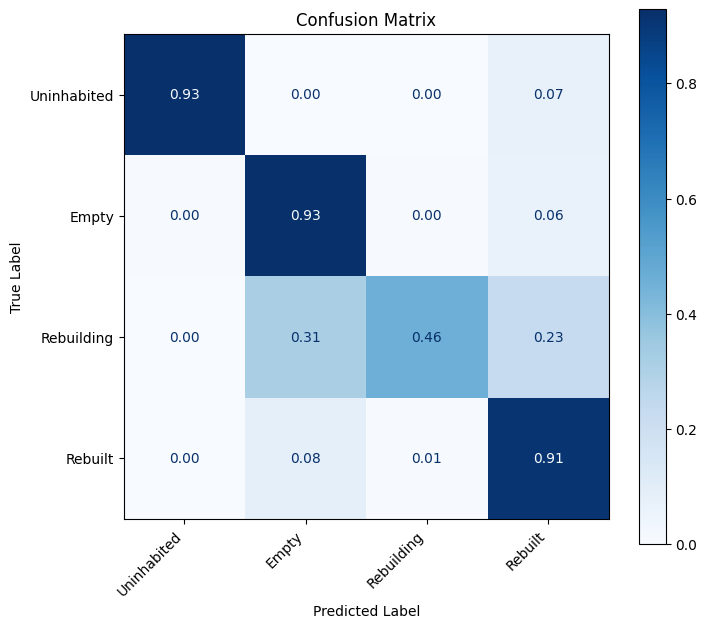

In [23]:
cm, cm_norm = confusion_matrix(
    model=net,
    device="cuda",
    class_names=class_names,                 
    validation_loader=validation_loader,     
    w_sequence=0.6,
    save_path="/scratch/user/al63rt.tran/cm_cnn_stm.png",
    dpi=300,
)